# Proyecto Inova - Predicción Temprana de Anoxia en Tilapia
Este modelo utiliza Inteligencia Artificial para predecir bajadas críticas en los niveles de Oxígeno Disuelto basándose en datos históricos. A diferencia de los sistemas tradicionales, este modelo **aprende de la tendencia histórica para predecir y alertar horas antes** de que el oxígeno baje a niveles letales.

**Nota:** Este notebook ahora utiliza un dataset de **Simulación Hidrodinámica Sintética** de ~2000 horas (3 meses) que incluye ciclos circadianos y eventos de anoxia modelados matemáticamente para probar la eficacia del modelo.

In [17]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# 1. Cargar Archivo Sintético Masivo
def load_json_to_df(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)
    records = [item['metadata'] for item in data if 'metadata' in item]
    df = pd.DataFrame(records)
    return df

df = load_json_to_df('C:\\Users\\k0nn0\\OneDrive\\Escritorio\\Misc\\Tec\\8vo\\IA\\IctioMind\\backend\\models_ML\\telemetria_sintetica_v3.json')

# 2. Preprocesamiento
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by='timestamp').reset_index(drop=True)

print(f"Total de registros históricos: {len(df)}")
df.head()

Total de registros históricos: 2000


,id_estanque,timestamp,ph_actual,temperatura_agua_actual,oxigeno_disuelto_actual,dureza_actual
0,1,2026-01-01 00:00:00,7.50,24.81,7.22,150.20
1,1,2026-01-01 01:00:00,7.49,25.71,6.69,150.29
2,1,2026-01-01 02:00:00,7.49,25.67,6.37,150.61
3,1,2026-01-01 03:00:00,7.49,26.78,6.29,150.78
4,1,2026-01-01 04:00:00,7.49,26.56,6.03,150.59


## Análisis Exploratorio de Datos (EDA)
Observamos los eventos de anoxia generados en la simulación.

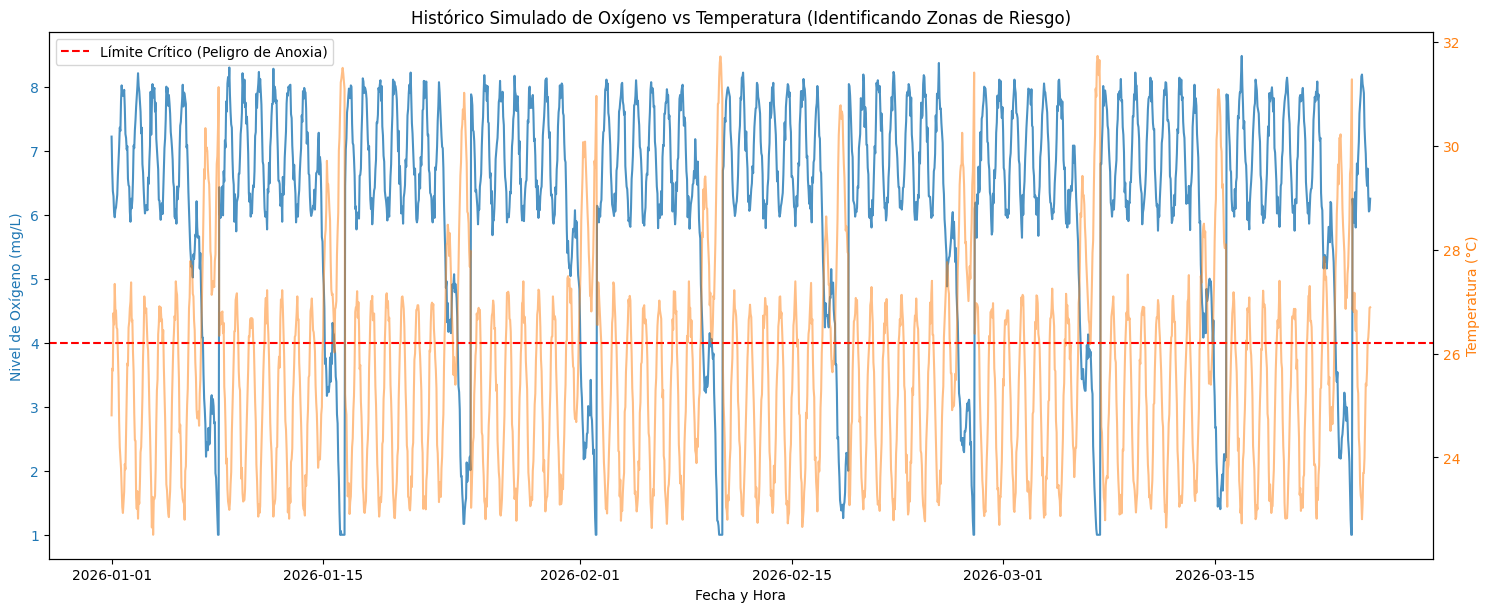

In [18]:
# Graficar comportamiento histórico del Oxígeno y la Temperatura
fig, ax1 = plt.subplots(figsize=(15, 6))

color = 'tab:blue'
ax1.set_xlabel('Fecha y Hora')
ax1.set_ylabel('Nivel de Oxígeno (mg/L)', color=color)
ax1.plot(df['timestamp'], df['oxigeno_disuelto_actual'], color=color, alpha=0.8)
ax1.axhline(y=4.0, color='red', linestyle='--', label='Límite Crítico (Peligro de Anoxia)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Temperatura (°C)', color=color)
ax2.plot(df['timestamp'], df['temperatura_agua_actual'], color=color, alpha=0.5)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Histórico Simulado de Oxígeno vs Temperatura (Identificando Zonas de Riesgo)')
plt.show()

## 1. Modelo Predictivo Avanzado (Random Forest con Ventanas de Tiempo / Lags)
 usaremos las últimas **3 horas de historia** (Lag 1, Lag 2, Lag 3) para predecir el futuro.

In [19]:
# ==============================================================================
# 1. MODELO PREDICTIVO AVANZADO (MULTI-OUTPUT RANDOM FOREST)
# Predice Oxígeno, Temperatura, pH y Dureza simultáneamente usando Lags.
# ==============================================================================

# Crear características de retardo temporal (Time Lags)
df_lag = df.copy()

# Vamos a mirar 3 horas hacia atrás para TODAS las variables
lags = 5
for i in range(1, lags + 1):
    df_lag[f'o2_lag_{i}'] = df_lag['oxigeno_disuelto_actual'].shift(i)
    df_lag[f'temp_lag_{i}'] = df_lag['temperatura_agua_actual'].shift(i)
    df_lag[f'ph_lag_{i}'] = df_lag['ph_actual'].shift(i)
    df_lag[f'dur_lag_{i}'] = df_lag['dureza_actual'].shift(i)

# Eliminamos registros sin pasado (las primeras 3 horas que se quedan en NaN)
df_lag = df_lag.dropna()

# --- A. DEFINIR LAS 12 VARIABLES DE ENTRADA (FEATURES / X) ---
lag_features = (
    [f'o2_lag_{i}' for i in range(1, lags + 1)] + 
    [f'temp_lag_{i}' for i in range(1, lags + 1)] +
    [f'ph_lag_{i}' for i in range(1, lags + 1)] +
    [f'dur_lag_{i}' for i in range(1, lags + 1)]
)
X_lag = df_lag[lag_features]

# --- B. DEFINIR LAS 4 VARIABLES DE SALIDA (TARGETS / Y) ---
target_features = [
    'oxigeno_disuelto_actual', 
    'temperatura_agua_actual', 
    'ph_actual', 
    'dureza_actual'
]
y_lag = df_lag[target_features]

# Dividir en entrenamiento y prueba SIN barajar (shuffle=False)
X_tr_lag, X_te_lag, y_tr_lag, y_te_lag = train_test_split(X_lag, y_lag, test_size=0.2, shuffle=False)

# Entrenar el Cerebro Predictivo Multi-Output
print("⏳ Entrenando modelo predictivo para las 4 variables simultáneas...")

# Aumentamos los árboles (estimators) de 150 a 200, y la profundidad (max_depth) de 10 a 15
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf_model.fit(X_tr_lag, y_tr_lag)

y_pred_rf = rf_model.predict(X_te_lag)

# --- C. EVALUACIÓN DESGLOSADA ---
print("\n✅ --- Evaluación Modelo Predictivo Integral (Multi-Output) ---")

# Calculamos el R2 Score para cada variable por separado
r2_scores = r2_score(y_te_lag, y_pred_rf, multioutput='raw_values')

print(f"Precisión (R2) para Oxígeno: {r2_scores[0]:.4f}")
print(f"Precisión (R2) para Temperatura: {r2_scores[1]:.4f}")
print(f"Precisión (R2) para pH: {r2_scores[2]:.4f}")
print(f"Precisión (R2) para Dureza: {r2_scores[3]:.4f}")
print(f"Precisión Global Media: {r2_scores.mean():.4f}")

joblib.dump(rf_model, 'C:\\Users\\k0nn0\\OneDrive\\Escritorio\\Misc\\Tec\\8vo\\IA\\IctioMind\\backend\\models_ML\\modelo_ictiomind_v3.joblib')
print("\n¡Nuevo Modelo Predictivo Integral Guardado Exitosamente!")

⏳ Entrenando modelo predictivo para las 4 variables simultáneas...

✅ --- Evaluación Modelo Predictivo Integral (Multi-Output) ---
Precisión (R2) para Oxígeno: 0.7749
Precisión (R2) para Temperatura: 0.8391
Precisión (R2) para pH: 0.7913
Precisión (R2) para Dureza: 0.9352
Precisión Global Media: 0.8351

¡Nuevo Modelo Predictivo Integral Guardado Exitosamente!


## Simulación de Alerta Temprana en el Dataset de Prueba


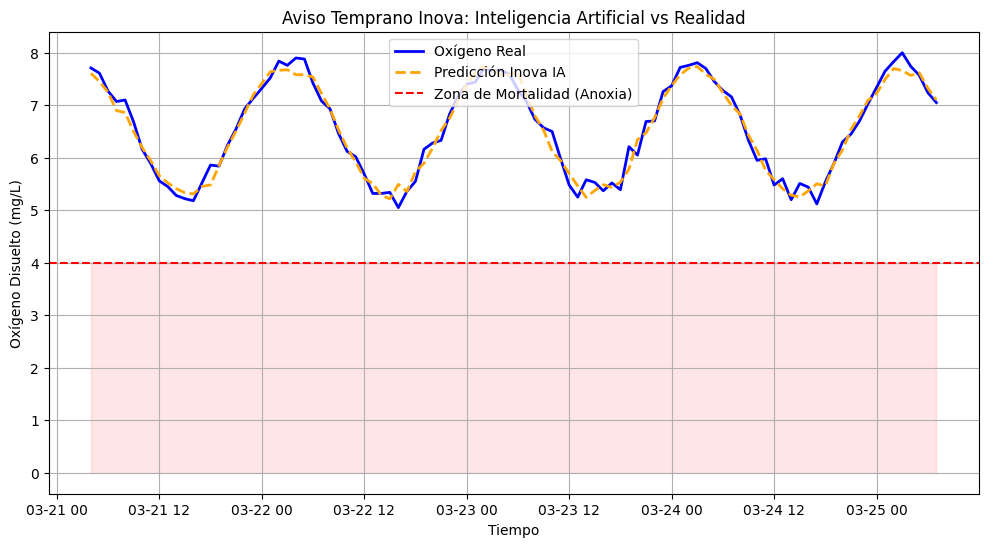

¡Modelo Predictivo Guardado Exitosamente!


In [ ]:
# Tomamos los últimos 100 registros del dataset de prueba para ver el detalle de predicción
test_subset = 100
timestamps_test = df_lag['timestamp'].iloc[-len(y_te_lag):].iloc[-test_subset:]
y_real = y_te_lag.iloc[-test_subset:]
y_pred = y_pred_rf[-test_subset:]

plt.figure(figsize=(12, 6))
plt.plot(timestamps_test, y_real, label='Oxígeno Real', color='blue', linewidth=2)
plt.plot(timestamps_test, y_pred, label='Predicción Inova IA', color='orange', linestyle='dashed', linewidth=2)
plt.axhline(y=4.0, color='red', linestyle='--', label='Zona de Mortalidad (Anoxia)')

# Rellenar zona de peligro
plt.fill_between(timestamps_test, 0, 4.0, color='red', alpha=0.1)

plt.title('Aviso Temprano Inova: Inteligencia Artificial vs Realidad')
plt.xlabel('Tiempo')
plt.ylabel('Oxígeno Disuelto (mg/L)')
plt.legend()
plt.grid(True)
plt.show()

# Guardar Modelo Final de Producción
joblib.dump(rf_model, 'C:/JosmarT/datasets/inova_predictive_rf.joblib')
print("¡Modelo Predictivo Guardado Exitosamente!")